In [1]:
import os
import random
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

import warnings
warnings.filterwarnings('ignore')

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 42
set_seed(seed)

train_path = r'D:\D-Documents\University\Sem_8\XAI\Assignment\Assignment_2\Data\jigsaw-multilingual-toxic-comment-classification\jigsaw-unintended-bias-train.csv'
columns_ = ['comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish', 'other_sexual_orientation']
toxicity_threshold = 0.5
best_threshold = 0.4 # From Part 1 optimizations

print("Loading Data...")
df = pd.read_csv(train_path)[columns_].dropna(subset=['toxic']).drop_duplicates(subset=['comment_text'])
df['toxic_binarized'] = (df['toxic'] >= toxicity_threshold).astype(int)

train_df, val_df = train_test_split(
    df, test_size=20000, train_size=100000, random_state=seed, stratify=df["toxic_binarized"]
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
print(f"Data loaded. Train size: {len(train_df)}, Val size: {len(val_df)}")

d:\D-Documents\University\sem7_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Data...
Data loaded. Train size: 100000, Val size: 20000


In [2]:
# Load clean model from Part 1/2
model_path = "./distilbert-toxic/distilbert-toxic-final"
print(f"Loading Clean Model from {model_path}...")
tokenizer = AutoTokenizer.from_pretrained(model_path)
clean_model = AutoModelForSequenceClassification.from_pretrained(model_path)

class ToxicDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.texts = dataframe["comment_text"].fillna("").astype(str).tolist()
        self.labels = dataframe["toxic_binarized"].astype(int).tolist() if "toxic_binarized" in dataframe.columns else [0]*len(self.texts)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx], max_length=self.max_length, truncation=True, padding="max_length", return_tensors="pt")
        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

val_dataset = ToxicDataset(val_df, tokenizer)

print("Getting clean model predictions on the full validation set...")
clean_trainer = Trainer(model=clean_model)
preds_output = clean_trainer.predict(val_dataset)
clean_preds_proba = torch.sigmoid(torch.tensor(preds_output.predictions[:, 1])).numpy()

# Filter for confidence >= 0.7 where predicted as toxic
val_df['clean_pred_prob'] = clean_preds_proba
val_df['clean_pred_toxic'] = (clean_preds_proba > best_threshold).astype(int)

high_conf_toxic = val_df[(val_df['clean_pred_toxic'] == 1) & (val_df['clean_pred_prob'] >= 0.7)]
print(f"Found {len(high_conf_toxic)} toxic comments properly detected with confidence >= 0.7")

# Random sample of 500 for evasion attack
attack1_sample = high_conf_toxic.sample(n=500, random_state=seed).copy()

Loading Clean Model from ./distilbert-toxic/distilbert-toxic-final...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 9454.41it/s]

Getting clean model predictions on the full validation set...


Found 745 toxic comments properly detected with confidence >= 0.7


In [3]:
from IPython.display import display

# Attack 1: Character-level evasion
def perturb(text):
    homoglyphs = {'a': '\u0430', 'e': '\u0435', 'o': '\u043e'} # Cyrillic lookalikes
    words = str(text).split()
    perturbed_words = []
    
    for word in words:
        new_word = ""
        for char in word:
            # Unicode homoglyph substitution
            c = homoglyphs.get(char, char)
            # Random character duplication (20% chance per char)
            if random.random() < 0.2:
                c = c * 2
            new_word += c
        
        # Zero-width space insertion (U+200B between every 2-3 characters)
        final_word = ""
        for i, char in enumerate(new_word):
            final_word += char
            if (i + 1) % 2 == 0 and i != len(new_word) - 1:
                final_word += '\u200b'
                
        perturbed_words.append(final_word)
    return " ".join(perturbed_words)

# Apply perturbation
print("Applying perturbations...")
attack1_sample['perturbed_text'] = attack1_sample['comment_text'].apply(perturb)

# Predict on perturbed comments
perturbed_df = attack1_sample.copy()
perturbed_df['comment_text'] = perturbed_df['perturbed_text'] # Overwrite for the dataset builder
perturbed_dataset = ToxicDataset(perturbed_df, tokenizer)

perturbed_preds_output = clean_trainer.predict(perturbed_dataset)
perturbed_probs = torch.sigmoid(torch.tensor(perturbed_preds_output.predictions[:, 1])).numpy()

attack1_sample['perturbed_prob'] = perturbed_probs
attack1_sample['perturbed_pred_toxic'] = (perturbed_probs > best_threshold).astype(int)

# Compute ASR
successful_attacks = attack1_sample[attack1_sample['perturbed_pred_toxic'] == 0]
asr = len(successful_attacks) / len(attack1_sample)

avg_conf_before = attack1_sample['clean_pred_prob'].mean()
avg_conf_after = attack1_sample['perturbed_prob'].mean()

# Deliverable table
asr_table = pd.DataFrame([{
    "Metric": "Value",
    "Total Sampled": len(attack1_sample),
    "Attack Success Rate (ASR)": f"{asr:.2%}",
    "Avg Confidence (Before)": f"{avg_conf_before:.4f}",
    "Avg Confidence (After)": f"{avg_conf_after:.4f}"
}])

print("### Attack 1: Character-level Evasion Results ###")
display(asr_table.set_index("Metric").T)

print("\nExample of perturbation:")
example = attack1_sample.iloc[0]
print("Original:", example['comment_text'])
print("Perturbed:", example['perturbed_text'])
print(f"Prob Before: {example['clean_pred_prob']:.4f} -> Prob After: {example['perturbed_prob']:.4f}")

Applying perturbations...


### Attack 1: Character-level Evasion Results ###


Metric,Value
Total Sampled,500
Attack Success Rate (ASR),94.60%
Avg Confidence (Before),0.8404
Avg Confidence (After),0.1517



Example of perturbation:
Original: What if someone posts a pile of horse s***?
Perturbed: Wh​hа​t if sо​оm​ее​оn​ее pp​оs​ts а pp​il​е оо​f hо​оr​rs​е s*​**​?
Prob Before: 0.8459 -> Prob After: 0.6217


In [4]:
print("### Attack 2: Label-flipping Poisoning ###")

poisoned_train_df = train_df.copy()

# Randomly select 5% of rows
num_to_poison = int(len(poisoned_train_df) * 0.05)
poison_indices = np.random.choice(poisoned_train_df.index, size=num_to_poison, replace=False)

# Flip labels (0 -> 1, 1 -> 0)
poisoned_train_df.loc[poison_indices, 'toxic_binarized'] = 1 - poisoned_train_df.loc[poison_indices, 'toxic_binarized']

print(f"Total training rows: {len(poisoned_train_df)}")
print(f"Poisoned training rows: {len(poison_indices)} ({len(poison_indices)/len(poisoned_train_df):.2%})")

# Load fresh distilbert-base-uncased model and tokenizer for training
print("\nLoading fresh distilbert-base-uncased model...")
fresh_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
poisoned_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# Create datasets for training the poisoned model
poisoned_train_dataset = ToxicDataset(poisoned_train_df, fresh_tokenizer)
fresh_val_dataset = ToxicDataset(val_df, fresh_tokenizer)

### Attack 2: Label-flipping Poisoning ###
Total training rows: 100000
Poisoned training rows: 5000 (5.00%)

Loading fresh distilbert-base-uncased model...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8922.53it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [5]:
def compute_metrics_training(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions[:, 1]
    preds = torch.sigmoid(torch.tensor(predictions)).numpy()
    preds_binary = (preds > 0.5).astype(int) # Standard 0.5 used during training loop phase
    
    return {
        'accuracy': accuracy_score(labels, preds_binary),
        'f1_macro': f1_score(labels, preds_binary, average='macro'),
    }

poisoned_training_args = TrainingArguments(
    output_dir="./distilbert-poisoned",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    seed=seed,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

poisoned_trainer = Trainer(
    model=poisoned_model,
    args=poisoned_training_args,
    train_dataset=poisoned_train_dataset,
    eval_dataset=fresh_val_dataset,
    compute_metrics=compute_metrics_training,
)

print("Beginning training of poisoned model... (This will take a while)")
poisoned_trainer.train()

Beginning training of poisoned model... (This will take a while)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.325186,0.167718,0.949750,0.795705
2,0.271607,0.161819,0.948050,0.804935
3,0.248381,0.179482,0.945700,0.810235


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.45it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=18750, training_loss=0.2656791933186849, metrics={'train_runtime': 1177.811, 'train_samples_per_second': 254.71, 'train_steps_per_second': 15.919, 'total_flos': 9935054899200000.0, 'train_loss': 0.2656791933186849, 'epoch': 3.0})

In [6]:
print("Evaluating clean vs poisoned models on the validation set...")

# Calculate metrics for the Clean Model (using the validation predictions generated in Cell 2)
# We test against the real validation set targets using the tuned best_threshold = 0.4
y_true = val_df['toxic_binarized']
y_pred_clean = val_df['clean_pred_toxic'] 

clean_acc = accuracy_score(y_true, y_pred_clean)
clean_f1 = f1_score(y_true, y_pred_clean, average='macro')
clean_cm = confusion_matrix(y_true, y_pred_clean, labels=[0,1])
clean_fnr = clean_cm[1,0] / (clean_cm[1,0] + clean_cm[1,1]) if (clean_cm[1,0] + clean_cm[1,1]) > 0 else 0

# Predictions for the Poisoned Model
poisoned_preds_output = poisoned_trainer.predict(fresh_val_dataset)
poisoned_probs = torch.sigmoid(torch.tensor(poisoned_preds_output.predictions[:, 1])).numpy()
y_pred_poisoned = (poisoned_probs > best_threshold).astype(int)

poisoned_acc = accuracy_score(y_true, y_pred_poisoned)
poisoned_f1 = f1_score(y_true, y_pred_poisoned, average='macro')
poisoned_cm = confusion_matrix(y_true, y_pred_poisoned, labels=[0,1])
poisoned_fnr = poisoned_cm[1,0] / (poisoned_cm[1,0] + poisoned_cm[1,1]) if (poisoned_cm[1,0] + poisoned_cm[1,1]) > 0 else 0

# Deliverable: before/after metric comparison table
comparison_data = {
    "Metric": ["Overall Accuracy", "Overall F1 (Macro)", "False Negative Rate (FNR)"],
    "Clean Model": [clean_acc, clean_f1, clean_fnr],
    "Poisoned Model": [poisoned_acc, poisoned_f1, poisoned_fnr],
    "Absolute Change": [poisoned_acc - clean_acc, poisoned_f1 - clean_f1, poisoned_fnr - clean_fnr]
}

comparison_df = pd.DataFrame(comparison_data)

print("### Attack 2: Poisoning Results (Clean vs. Poisoned) ###")
display(comparison_df.round(4))

Evaluating clean vs poisoned models on the validation set...


### Attack 2: Poisoning Results (Clean vs. Poisoned) ###


,Metric,Clean Model,Poisoned Model,Absolute Change
0,Overall Accuracy,0.9486,0.9466,-0.0020
1,Overall F1 (Macro),0.8156,0.8150,-0.0005
2,False Negative Rate (FNR),0.3800,0.3556,-0.0244


### Adversarial Attacks: Threat Model Analysis

**Which attack is more operationally dangerous for a live platform, and why?**  
The **Character-level Evasion Attack (Attack 1)** is vastly more operationally dangerous for a live social media platform because of its asymmetrical and highly realistic threat model.

1. **Barrier to Entry & Threat Actor:** Evasion requires almost zero external access. Any bad actor (trolls, automated bots, organized harassment campaigns) can execute it purely by modifying the text entered in the platform's user interface. It requires minimal technical sophistication and expertly exploits intrinsic algorithmic flaws in NLP tokenizer architectures (subword vocabulary gaps).
2. **Scalability:** Evasion targets inference time. Attackers can build cheap scripts to automatically inject homoglyphs and zero-width spaces into thousands of posts per second, entirely bypassing moderation queues. This inflicts immediate, unmitigated damage to users before engineers can hot-patch the filters.

**Contrast with Poisoning:**  
A **Label-flipping Poisoning Attack (Attack 2)** is catastrophic if deployed successfully, but highly impractical as an external threat route. It fundamentally requires deep read/write access to the platform's proprietary data pipelines, ML artifact clusters, or outsourced annotation streams. This requires heavily compromising the inner supply chain. While extremely risky, poisoning is largely an "insider threat", which makes it comparatively rare opposed to billions of external actors attempting client-side rule evasions.

**Implication for Prioritizing Defenses:**  
Defenses must predominantly prioritize the **front-line evasion attack surface**. Safe harbor practices imply platforms must invest heavily in powerful text normalizers built *upstream* of the model pipeline (e.g., actively stripping unprintable Unicode characters like U+200B zero-width spaces, converting diverse homoglyphs to standard Latin equivalents, spell-fixing erratic duplicated letter runs, and applying rules engines alongside AI). Conversely, securing models against poisoning demands rigorous zero-trust data architectures and anomaly-scrubbing data pipelines deeper inside closed-server security architectures.

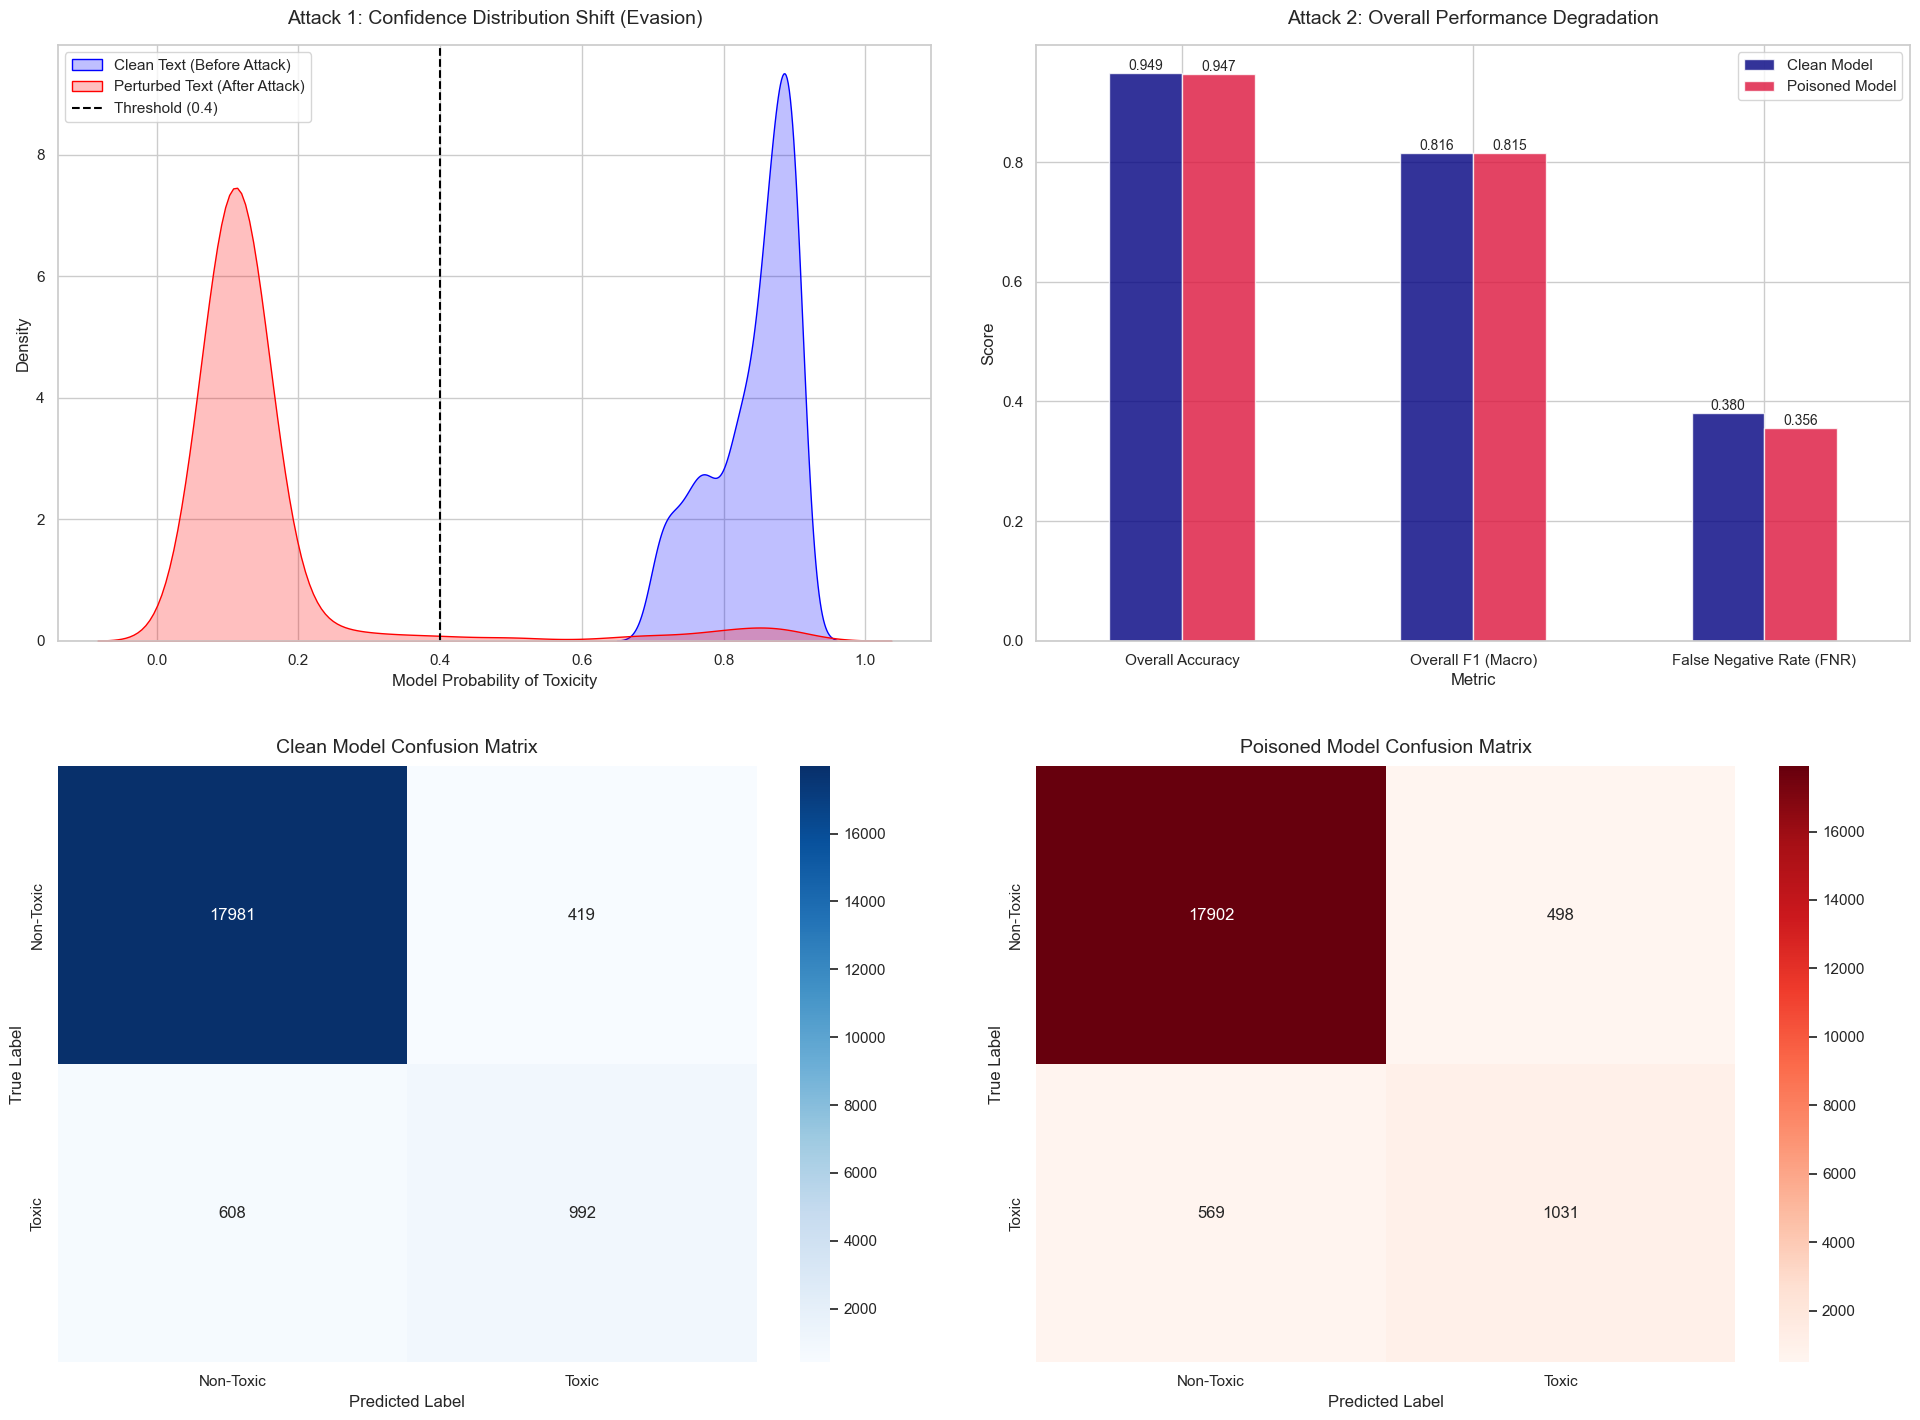

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots for the different perspectives
fig = plt.figure(figsize=(20, 15))

# --- Perspective 1: Attack 1 Confidence Shift ---
# Plotting the density of prediction probabilities before and after character-level evasion
ax1 = plt.subplot(2, 2, 1)
sns.kdeplot(attack1_sample['clean_pred_prob'], fill=True, label='Clean Text (Before Attack)', color='blue', ax=ax1)
sns.kdeplot(attack1_sample['perturbed_prob'], fill=True, label='Perturbed Text (After Attack)', color='red', ax=ax1)
ax1.axvline(best_threshold, color='black', linestyle='--', label=f'Threshold ({best_threshold})')
ax1.set_title('Attack 1: Confidence Distribution Shift (Evasion)', fontsize=14, pad=15)
ax1.set_xlabel('Model Probability of Toxicity')
ax1.set_ylabel('Density')
ax1.legend()

# --- Perspective 2: Attack 2 Performance Metrics Comparison ---
# Grouped bar chart comparing Clean vs Poisoned metrics
ax2 = plt.subplot(2, 2, 2)
metrics_to_plot = comparison_df.iloc[:, 1:3] # Exclude 'Metric' and 'Absolute Change'
metrics_to_plot.index = comparison_df['Metric']
metrics_to_plot.plot(kind='bar', ax=ax2, color=['navy', 'crimson'], alpha=0.8)
ax2.set_title('Attack 2: Overall Performance Degradation', fontsize=14, pad=15)
ax2.set_ylabel('Score')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)
ax2.legend(['Clean Model', 'Poisoned Model'])

# --- Perspective 3: Attack 2 Confusion Matrices (Clean) ---
ax3 = plt.subplot(2, 2, 3)
sns.heatmap(clean_cm, annot=True, fmt='d', cmap='Blues', ax=ax3, 
            xticklabels=['Non-Toxic', 'Toxic'], yticklabels=['Non-Toxic', 'Toxic'])
ax3.set_title('Clean Model Confusion Matrix', fontsize=14, pad=10)
ax3.set_xlabel('Predicted Label')
ax3.set_ylabel('True Label')

# --- Perspective 4: Attack 2 Confusion Matrices (Poisoned) ---
ax4 = plt.subplot(2, 2, 4)
sns.heatmap(poisoned_cm, annot=True, fmt='d', cmap='Reds', ax=ax4, 
            xticklabels=['Non-Toxic', 'Toxic'], yticklabels=['Non-Toxic', 'Toxic'])
ax4.set_title('Poisoned Model Confusion Matrix', fontsize=14, pad=10)
ax4.set_xlabel('Predicted Label')
ax4.set_ylabel('True Label')

plt.tight_layout(pad=3.0)
plt.show()